# Select Positive Examples from Eval Logs

Loads evaluation logs, filters for correct (positive) examples, and displays them with pandas.

In [38]:
all_samples[0]['triples']

[' <List of mountains in Iceland> <description> <Wikimedia list article> .',
 ' <List of mountains in Iceland> <is a list of> <Mountain> .',
 ' <Denali> <elevation above sea level> <+6190> .',
 ' <Mount Logan> <elevation above sea level> <+5959> .',
 ' <Mount Saint Elias> <elevation above sea level> <+5489> .',
 ' <Mount Bona> <elevation above sea level> <+4986> .',
 ' <Mount Churchill> <elevation above sea level> <+4744> .',
 ' <Mount Fairweather> <elevation above sea level> <+4653> .',
 ' <Mount Hubbard> <elevation above sea level> <+4557> .',
 ' <Mount Vancouver> <elevation above sea level> <+4810> .',
 ' <Mount Foraker> <elevation above sea level> <+5304> .',
 ' <Mount Blackburn> <elevation above sea level> <+4996> .',
 ' <Mount Sanford> <description> <Wikimedia disambiguation page> .',
 ' <Mount Sanford (Alaska)> <elevation above sea level> <+4949> .',
 ' <Mount Drum> <elevation above sea level> <+3660> .',
 ' <Mount Wrangell> <elevation above sea level> <+4317> .',
 ' <Mount Edge

In [11]:
import json
import pandas as pd
from pathlib import Path

EVAL_LOGS = [
    "../logs/mintaka_train_eval_qwen36_35b.out.0.enriched",
    "../logs/mintaka_test_eval_qwen36_35b.out.3.enriched",
]

In [12]:
def load_eval_log(path):
    with open(path) as f:
        lines = f.readlines()
    samples = []
    for l in lines:
        if 'macro_precision' in l:
            continue
        d = json.loads(l)
        if 'input_sample' in d:
            samples.append(d)
    return samples

all_samples = []
for p in EVAL_LOGS:
    samples = load_eval_log(p)
    source = Path(p).stem
    for s in samples:
        s['_source'] = source
    all_samples.extend(samples)
    print(f"{p}: {len(samples)} samples")

print(f"\nTotal: {len(all_samples)} samples")

../logs/mintaka_train_eval_qwen36_35b.out.0.enriched: 14000 samples
../logs/mintaka_test_eval_qwen36_35b.out.3.enriched: 4000 samples

Total: 18000 samples


In [13]:
positives = [s for s in all_samples if s['evaluation']['correct'] == 1]
negatives = [s for s in all_samples if s['evaluation']['correct'] == 0]
dont_know = [s for s in all_samples if s['evaluation'].get('dont_know') == 1]

print(f"Positive (correct):     {len(positives)}")
print(f"Negative (incorrect):   {len(negatives)}")
print(f"  of which dont_know:   {len(dont_know)}")

Positive (correct):     1737
Negative (incorrect):   16263
  of which dont_know:   68


In [14]:
positives[0]['input_sample']


{'question': 'What year was the first book of the A Song of Ice and Fire series published?',
 'answer': '1996',
 'complexityType': 'generic',
 'category': 'books'}

In [29]:
df = pd.DataFrame([{
    'question': s['question'],
    'gt_answer': s['gt_answer'],
    'prediction': s['prediction'],
    'full_prediction': s['full_prediction'],
    'f1': s['evaluation']['f1'],
    'precision': s['evaluation']['precision'],
    'recall': s['evaluation']['recall'],
    'dont_know': s['evaluation']['dont_know'],
    'complexityType': s['input_sample'].get('complexityType'),
    'category': s['input_sample'].get('category'),
    'source': s['_source'],
} for s in positives])

print(f"Positive examples: {len(df)}")
df.head(10)

Positive examples: 1737


,question,gt_answer,prediction,full_prediction,f1,precision,recall,dont_know,complexityType,category,source
0,What year was the first book of the A Song of ...,1996,[1996],"Reasoning: To answer this question, I need to ...",1.0,1.0,1.0,0,generic,books,mintaka_train_eval_qwen36_35b.out.0
1,Is Venus Williams older than Serena Williams?,Yes,[Yes],"Reasoning: To answer this question, I need to ...",1.0,1.0,1.0,0,comparative,sports,mintaka_train_eval_qwen36_35b.out.0
2,Did the movie Moana come out before 2015?,No,[No],"Reasoning: To answer this question, I need to ...",1.0,1.0,1.0,0,comparative,movies,mintaka_train_eval_qwen36_35b.out.0
3,"Which movie made more money, Joker or Suicide ...",Joker,[Joker],"Reasoning: To answer this question, I need to ...",1.0,1.0,1.0,0,comparative,movies,mintaka_train_eval_qwen36_35b.out.0
4,Was Friday the 13th released the same year as ...,No,[No],"Reasoning: To answer this question, I need to ...",1.0,1.0,1.0,0,comparative,movies,mintaka_train_eval_qwen36_35b.out.0
5,Did Scream come out before 2000?,Yes,[Yes],"Reasoning: To answer this question, I need to ...",1.0,1.0,1.0,0,comparative,movies,mintaka_train_eval_qwen36_35b.out.0
6,"Who is older, Drew Barrymore or Neve Campbell?",Neve Campbell,[Neve Campbell],"Reasoning: To determine who is older, I need t...",1.0,1.0,1.0,0,comparative,movies,mintaka_train_eval_qwen36_35b.out.0
7,"Who is older, Jodie Foster or Julia Roberts?",Jodie Foster,[Jodie Foster],"Reasoning: To determine who is older, I need t...",1.0,1.0,1.0,0,comparative,movies,mintaka_train_eval_qwen36_35b.out.0
8,"Who is taller, Angelina Jolie or Brad Pitt?",Brad Pitt,[Brad Pitt],"Reasoning: To answer this question, I need to ...",1.0,1.0,1.0,0,comparative,movies,mintaka_train_eval_qwen36_35b.out.0
9,Is Jake Gyllenhaal older than Maggie Gyllenhaal?,No,[No],"Reasoning: To answer this question, I need to ...",1.0,1.0,1.0,0,comparative,movies,mintaka_train_eval_qwen36_35b.out.0


In [30]:
df['complexityType'].value_counts()

complexityType
comparative     698
generic         508
yesno           237
multihop        137
intersection     76
ordinal          44
count            24
superlative       9
difference        4
Name: count, dtype: int64

In [36]:
for _, row in df[df["complexityType"] == "count"].iterrows():
    print("question:", row["question"])
    print("prediction:", row["prediction"])
    print("full_prediction:", row["full_prediction"])
    print("---")

question: How many screenwriters does the movie Pulp Fiction have?
prediction: ['2']
full_prediction: Reasoning: To answer this question, I need to find the screenwriters of the movie "Pulp Fiction" and count them.

Fact: <Pulp Fiction> <screenwriter> <Quentin Tarantino> .
Fact: <Pulp Fiction> <screenwriter> <Roger Avary> .
I found two screenwriters: Quentin Tarantino and Roger Avary.

Answer: ["2"]
---
question: How many Academy Awards did Avatar win?
prediction: ['3']
full_prediction: Reasoning: To answer this question, I need to find the number of Academy Awards won by the movie "Avatar".

Fact: <Avatar> <instance of> <religious concept (abstract object associated with religion)> .
Wait, that's not right. Let me try again.
Fact: <Avatar> <description> <material appearance or incarnation of a deity on earth in Hinduism> .
This is the religious concept. I need the movie.
Fact: <Avatar (2009 film)> <description> <2009 film directed by James Cameron> .
Fact: <Avatar (2009 film)> <award 

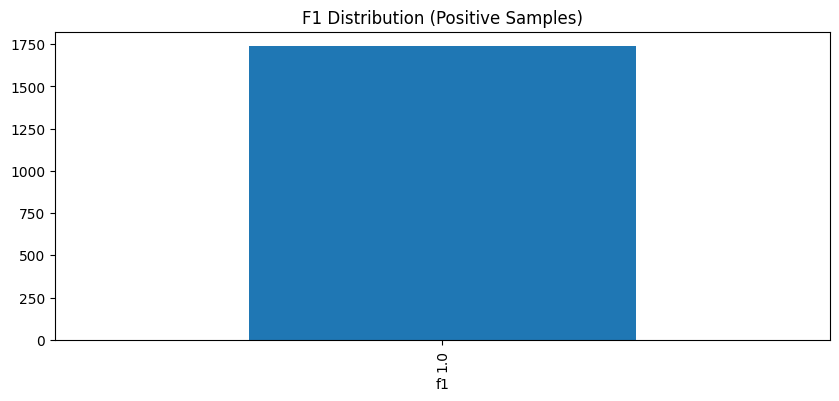

In [16]:
# Distribution of F1 scores among positives
df['f1'].value_counts().sort_index().plot(kind='bar', title='F1 Distribution (Positive Samples)', figsize=(10, 4));

In [6]:
# Samples with full generation
def show_sample(idx):
    s = positives[idx]
    print(f"Question: {s['question']}")
    print(f"Ground truth: {s['gt_answer']}")
    print(f"Prediction: {s['prediction']}")
    print(f"F1: {s['evaluation']['f1']}")
    print(f"\nFull generation:\n{s['full_prediction']}")

show_sample(0)

Question: What year was the first book of the A Song of Ice and Fire series published?
Ground truth: 1996
Prediction: ['1996']
F1: 1.0

Full generation:
Reasoning: To answer this question, I need to identify the first book in the "A Song of Ice and Fire" series and then find its publication year.

Fact: <A Song of Ice and Fire> <has part(s)> <A Game of Thrones> .
Fact: <A Game of Thrones> <publication date> <1996-08-06T00:00:00Z> .
Answer: ["1996"]


In [ ]:
# Save positive samples as JSONL for downstream use
OUTPUT = "../logs/positive_samples.jsonl"
with open(OUTPUT, "w") as f:
    for s in positives:
        f.write(json.dumps({
            "question": s["question"],
            "gt_answer": s["gt_answer"],
            "prediction": s["prediction"],
            "full_prediction": s["full_prediction"],
            "prompt": s["prompt"],
            "complexityType": s['input_sample'].get('complexityType'),
            "category": s['input_sample'].get('category'),
            "evaluation": s["evaluation"],
        }) + "\n")
print(f"Saved {len(positives)} positive samples to {OUTPUT}")

In [ ]:
# Show negatives too if needed
neg_df = pd.DataFrame([{
    'question': s['question'],
    'gt_answer': s['gt_answer'],
    'prediction': s['prediction'],
    'f1': s['evaluation']['f1'],
    'dont_know': s['evaluation']['dont_know'],
    'complexityType': s['input_sample'].get('complexityType'),
    'category': s['input_sample'].get('category'),
    'source': s['_source'],
} for s in negatives])
print(f"Negative examples: {len(neg_df)}")
neg_df.head(10)